# U23AI035 - LAB 4 - RAI

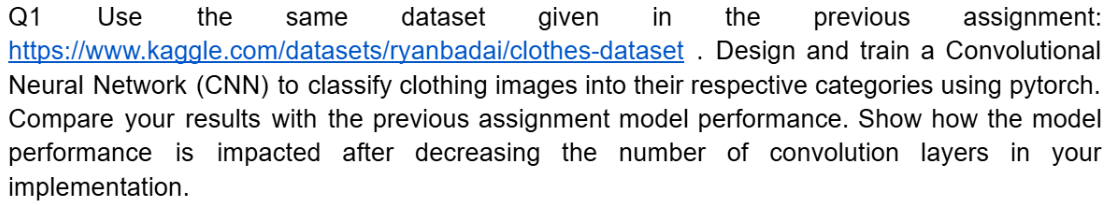

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
dataset = ImageFolder(root="Clothes_Dataset", transform=transform)

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

In [4]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

In [5]:
num_classes = len(dataset.classes)

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [7]:
def train(model, loader, optimizer, criterion, epochs=10):
    model.train()
    for _ in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

In [8]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = torch.argmax(out, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    return f1_score(y_true, y_pred, average="macro")

In [9]:
model = CNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train(model, train_loader, optimizer, criterion)

KeyboardInterrupt: 

In [10]:
f1 = evaluate(model, test_loader)
print("Macro F1:", f1)

Macro F1: 0.5507832598606396


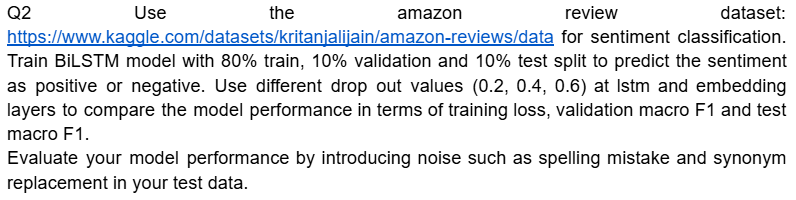

In [11]:
import pandas as pd
import numpy as np
import re
import random
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [12]:
DATA_PATH = "train.csv"
df = pd.read_csv(DATA_PATH)

In [13]:
df.head()

,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
0,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
1,2,Amazing!,This soundtrack is my favorite music of all ti...
2,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
3,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
4,2,an absolute masterpiece,I am quite sure any of you actually taking the...


In [14]:
df.columns = ['polarity', 'title', 'text']

In [15]:
df = df[['polarity', 'text']]
df.dropna(inplace=True)

In [16]:
def label_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return None  # Drop neutral

In [17]:
df['sentiment'] = df['polarity'].apply(label_sentiment)
df.dropna(inplace=True)

texts = df['text'].tolist()
# Convert labels to 0-indexed (subtract 1 to map 1,2 -> 0,1)
labels = (df['polarity'].astype(int) - 1).tolist()

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

In [19]:
texts = [clean_text(t) for t in texts]

In [20]:
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels,
    test_size=0.10,
    stratify=labels,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.111,
    stratify=y_temp,
    random_state=42
)

In [21]:
def yield_tokens(data):
    for text in data:
        yield text.split()

In [22]:
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<pad>": 0, "<unk>": 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

In [23]:
vocab = build_vocab(X_train)

In [24]:
MAX_LEN = 200

def encode(text):
    tokens = text.split()
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]
    ids = ids[:MAX_LEN]
    return ids + [vocab["<pad>"]] * (MAX_LEN - len(ids))

In [25]:
X_train_enc = [encode(t) for t in X_train]
X_val_enc   = [encode(t) for t in X_val]
X_test_enc  = [encode(t) for t in X_test]

In [26]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [27]:
train_loader = DataLoader(ReviewDataset(X_train_enc, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(ReviewDataset(X_val_enc, y_val), batch_size=64)
test_loader  = DataLoader(ReviewDataset(X_test_enc, y_test), batch_size=64)

In [28]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)

        _, (h_n, _) = self.lstm(x)

        h_forward = h_n[-2]
        h_backward = h_n[-1]

        h = torch.cat((h_forward, h_backward), dim=1)
        return self.fc(h)

In [29]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x, y in loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = torch.argmax(out, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    return f1_score(y_true, y_pred, average="macro")

In [31]:
dropouts = [0.2, 0.4, 0.6]
results = {}

In [ ]:
for d in dropouts:
    print(f"\nTraining with Dropout = {d}")

    model = BiLSTM(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_dim=128,
        dropout=d
    )

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_f1 = evaluate(model, val_loader)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")

    test_f1 = evaluate(model, test_loader)
    results[d] = (train_loss, val_f1, test_f1)


Training with Dropout = 0.2


c:\Users\JAIVAL CHAUHAN\.conda\envs\env-pt\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [ ]:
def spelling_noise(text):
    words = text.split()
    if len(words) == 0:
        return text
    i = random.randint(0, len(words)-1)
    if len(words[i]) > 1:
        words[i] = words[i][:-1]
    return " ".join(words)

In [ ]:
X_test_noisy = [spelling_noise(t) for t in X_test]
X_test_noisy_enc = [encode(t) for t in X_test_noisy]

noisy_loader = DataLoader(
    ReviewDataset(X_test_noisy_enc, y_test),
    batch_size=64
)

noisy_f1 = evaluate(model, noisy_loader)
print("Macro F1 on Noisy Test Data:", noisy_f1)

In [ ]:
print("\nFinal Results")
for d, res in results.items():
    print(f"Dropout {d} → Train Loss: {res[0]:.4f}, Val F1: {res[1]:.4f}, Test F1: {res[2]:.4f}")